# Block shuffling vs. full random shuffling — an entropy simulation

This notebook simulates the **block random shuffling** strategy (contiguous reads + shuffle buffer, as used for
shuffling very large on-disk datasets) and compares its shuffling quality against a **full random shuffle**.

**Dataset.** An int array of 100 mio elements consisting of `N_BLOCKS` (default 20) equally sized blocks.
Every element of a block holds the same distinct integer value, i.e. neighboring elements are perfectly
(auto)correlated — a worst case for shuffling.

**Strategies.**

- *Full random shuffle*: all elements are permuted uniformly at random (gold standard, requires random access
  to the whole dataset).
- *Block random shuffle*: contiguous read blocks of `READ_BLOCK_SIZE` (default 4096) elements are loaded from
  *random* positions of the dataset into a shuffle buffer of `SHUFFLE_BUFFER_SIZE` (default 2 097 152) elements.
  Output elements are drawn uniformly at random from the buffer, which is refilled block-wise as it drains.

**Metric.** Local Shannon entropy of the int values, computed over non-overlapping windows along the shuffled
stream. A good shuffle produces windows containing values from many different blocks, i.e. entropy close to
`log2(N_BLOCKS)` ≈ 4.32 bits at every position of the stream.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

# --- Simulation parameters ---------------------------------------------------
N_ELEMENTS = 100_000_000  # total dataset size: 100 mio elements
N_BLOCKS = 20  # number of autocorrelated blocks the dataset consists of
READ_BLOCK_SIZE = 4096  # contiguous chunk read per (simulated) I/O operation
SHUFFLE_BUFFER_SIZE = 2_097_152  # capacity of the in-memory shuffle buffer
ENTROPY_WINDOW = 50_000  # window size for the local entropy estimation
SEED = 0

rng = np.random.default_rng(SEED)


def human_readable(n):
    """Format an element count like 512 as '512', 4096 as '4K', 1048576 as '1M'."""
    if n >= 2**20:
        return f"{n // 2**20}M"
    if n >= 2**10:
        return f"{n // 2**10}K"
    return str(n)

dataset: 100,000,000 elements, 95 MiB, 20 blocks of 5,000,000 elements


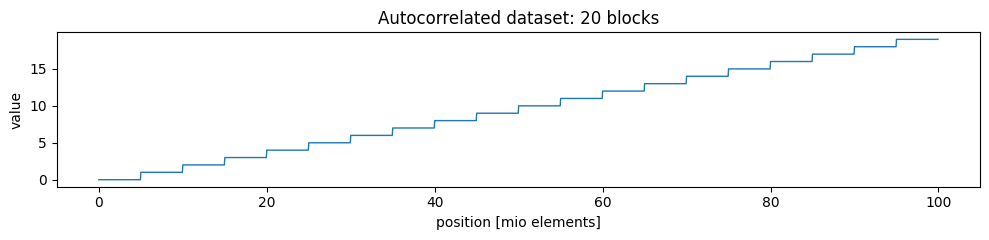

In [2]:
assert N_ELEMENTS % N_BLOCKS == 0
assert N_BLOCKS <= 127  # values are stored as int8

block_length = N_ELEMENTS // N_BLOCKS
# one distinct int value per block -> maximal autocorrelation within blocks,
# no correlation between blocks
dataset = np.repeat(np.arange(N_BLOCKS, dtype=np.int8), block_length)

print(f"dataset: {dataset.size:,} elements, {dataset.nbytes / 2**20:.0f} MiB, "
      f"{N_BLOCKS} blocks of {block_length:,} elements")

# visualize the block structure on a strided subsample
step = N_ELEMENTS // 2000
plt.figure(figsize=(10, 2.5))
plt.plot(np.arange(0, N_ELEMENTS, step) / 1e6, dataset[::step], lw=1)
plt.xlabel("position [mio elements]")
plt.ylabel("value")
plt.title(f"Autocorrelated dataset: {N_BLOCKS} blocks")
plt.tight_layout()
plt.show()

## 1. Full random shuffle (gold standard)

In [3]:
t0 = time.perf_counter()
shuffled_full = dataset.copy()
rng.shuffle(shuffled_full)  # uniform random permutation of all elements
print(f"full random shuffle took {time.perf_counter() - t0:.1f} s")

full random shuffle took 9.4 s


## 2. Block random shuffle

Simulation of the streaming algorithm:

1. **Refill:** while the buffer has room for another read block, read one contiguous block of
   `READ_BLOCK_SIZE` elements from a uniformly random (not yet read) position of the dataset into the buffer.
2. **Emit:** draw `READ_BLOCK_SIZE` elements uniformly at random (without replacement) from the buffer and
   append them to the output stream.

Because every correlation block (5 mio elements) is much larger than a read block, each read block contains
(essentially) a single value; we therefore track only the per-value *counts* of the unread dataset and of the
buffer instead of individual elements. Emitting a batch is then a single draw from a multivariate
hypergeometric distribution, which keeps the simulation fast. Elements within one emitted batch are shuffled
before being appended, matching the random emission order of the real algorithm.

In [4]:
def block_random_shuffle(dataset, n_blocks, read_block_size, buffer_size, rng):
    """Simulate block random shuffling of ``dataset``.

    Reads contiguous blocks of ``read_block_size`` elements from random dataset
    positions into a shuffle buffer of ``buffer_size`` elements and emits random
    elements from the buffer. Returns the shuffled stream.
    """
    n = len(dataset)
    unread = np.bincount(dataset, minlength=n_blocks).astype(np.int64)  # per value, not yet read
    buffered = np.zeros(n_blocks, dtype=np.int64)  # per value, currently in the shuffle buffer
    values = np.arange(n_blocks, dtype=dataset.dtype)
    out = np.empty_like(dataset)

    n_unread = int(unread.sum())
    n_buffered = 0
    pos = 0
    while pos < n:
        # refill buffer with randomly positioned contiguous read blocks
        while n_unread > 0 and n_buffered + read_block_size <= buffer_size:
            c = rng.choice(n_blocks, p=unread / n_unread)  # random position ~ value proportional to unread share
            take = min(read_block_size, unread[c])
            unread[c] -= take
            buffered[c] += take
            n_unread -= take
            n_buffered += take
        # emit a batch of random elements from the buffer (without replacement)
        emit = min(read_block_size, n_buffered, n - pos)
        counts = rng.multivariate_hypergeometric(buffered, emit)
        buffered -= counts
        n_buffered -= emit
        batch = np.repeat(values, counts)
        rng.shuffle(batch)  # random emission order within the batch
        out[pos : pos + emit] = batch
        pos += emit
    return out


t0 = time.perf_counter()
shuffled_block = block_random_shuffle(dataset, N_BLOCKS, READ_BLOCK_SIZE, SHUFFLE_BUFFER_SIZE, rng)
print(f"block random shuffle took {time.perf_counter() - t0:.1f} s")
assert np.array_equal(np.bincount(shuffled_block), np.bincount(dataset))  # same elements, new order

block random shuffle took 4.8 s


## 3. Comparison: local entropy along the shuffled streams

Shannon entropy $H = -\sum_v p_v \log_2 p_v$ of the int values in non-overlapping windows of
`ENTROPY_WINDOW` elements. The maximal possible value is $\log_2$(`N_BLOCKS`) ≈ 4.32 bits, reached when every
window contains all block values in equal proportion.

In [5]:
def windowed_entropy(stream, window, n_values):
    """Shannon entropy (bits) of the int values per non-overlapping window."""
    n_windows = len(stream) // window
    trimmed = stream[: n_windows * window].reshape(n_windows, window)
    # single bincount over (window_id, value) pairs -> counts per window and value
    keys = np.arange(n_windows, dtype=np.int32)[:, None] * n_values + trimmed
    counts = np.bincount(keys.ravel(), minlength=n_windows * n_values).reshape(n_windows, n_values)
    p = counts / window
    with np.errstate(divide="ignore"):
        logp = np.where(p > 0, np.log2(p), 0.0)
    return -(p * logp).sum(axis=1)


streams = {
    "unshuffled (reference)": dataset,
    "full random shuffle": shuffled_full,
    "block random shuffle": shuffled_block,
}
entropies = {name: windowed_entropy(s, ENTROPY_WINDOW, N_BLOCKS) for name, s in streams.items()}
max_entropy = np.log2(N_BLOCKS)

print(f"max possible entropy: log2({N_BLOCKS}) = {max_entropy:.4f} bits")
for name, h in entropies.items():
    print(f"{name:>24}: mean = {h.mean():.4f} bits, std = {h.std():.4f} "
          f"({h.mean() / max_entropy:.2%} of max)")

max possible entropy: log2(20) = 4.3219 bits
  unshuffled (reference): mean = 0.0000 bits, std = 0.0000 (0.00% of max)
     full random shuffle: mean = 4.3217 bits, std = 0.0001 (99.99% of max)
    block random shuffle: mean = 4.3083 bits, std = 0.0044 (99.68% of max)


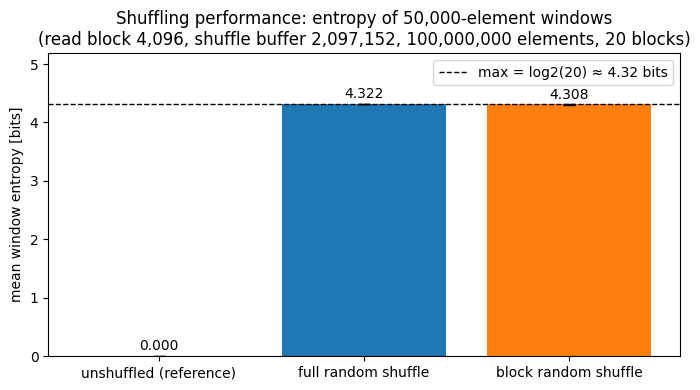

In [6]:
names = list(entropies)
means = [entropies[n].mean() for n in names]
stds = [entropies[n].std() for n in names]
colors = ["gray", "tab:blue", "tab:orange"]

plt.figure(figsize=(7, 4))
plt.bar(names, means, yerr=stds, capsize=4, color=colors)
plt.axhline(max_entropy, ls="--", c="k", lw=1,
            label=f"max = log2({N_BLOCKS}) ≈ {max_entropy:.2f} bits")
for i, m in enumerate(means):
    plt.text(i, m + 0.1, f"{m:.3f}", ha="center")
plt.ylabel("mean window entropy [bits]")
plt.ylim(0, max_entropy * 1.2)
plt.legend()
plt.title(
    f"Shuffling performance: entropy of {ENTROPY_WINDOW:,}-element windows\n"
    f"(read block {READ_BLOCK_SIZE:,}, shuffle buffer {SHUFFLE_BUFFER_SIZE:,}, "
    f"{N_ELEMENTS:,} elements, {N_BLOCKS} blocks)"
)
plt.tight_layout()
plt.show()

## 4. Shuffle quality vs. read block size

The read block size controls how many independently positioned read blocks are resident in the shuffle buffer
(`SHUFFLE_BUFFER_SIZE / READ_BLOCK_SIZE`). Sweeping the read block size (buffer size fixed) shows how shuffle
quality degrades once only a few read blocks — and therefore only a few different correlation blocks — fit into
the buffer.

In [7]:
# read block sizes from 1 KiB up to the buffer size (must fit into the shuffle buffer)
READ_BLOCK_SIZES = 2 ** np.arange(10, int(np.log2(SHUFFLE_BUFFER_SIZE)) + 1)

sweep = []
for rbs in READ_BLOCK_SIZES:
    t0 = time.perf_counter()
    stream = block_random_shuffle(dataset, N_BLOCKS, int(rbs), SHUFFLE_BUFFER_SIZE,
                                  np.random.default_rng(SEED))
    h = windowed_entropy(stream, ENTROPY_WINDOW, N_BLOCKS)
    sweep.append({"read_block_size": int(rbs), "mean_entropy": h.mean(), "std_entropy": h.std()})
    print(f"read block {int(rbs):>9,}: mean window entropy {h.mean():.4f} bits "
          f"({h.mean() / max_entropy:6.2%} of max), took {time.perf_counter() - t0:5.1f} s")

read block     1,024: mean window entropy 4.3184 bits (99.92% of max), took   9.0 s


read block     2,048: mean window entropy 4.3157 bits (99.86% of max), took   5.4 s


read block     4,096: mean window entropy 4.3094 bits (99.71% of max), took   4.3 s


read block     8,192: mean window entropy 4.2963 bits (99.41% of max), took   4.0 s


read block    16,384: mean window entropy 4.2720 bits (98.85% of max), took   3.5 s


...

read block   131,072: mean window entropy 3.8278 bits (88.57% of max), took   3.6 s


read block   262,144: mean window entropy 3.4440 bits (79.69% of max), took   3.5 s


read block   524,288: mean window entropy 2.8270 bits (65.41% of max), took   3.5 s


read block 1,048,576: mean window entropy 1.5818 bits (36.60% of max), took   3.5 s


read block 2,097,152: mean window entropy 0.0229 bits ( 0.53% of max), took   3.5 s


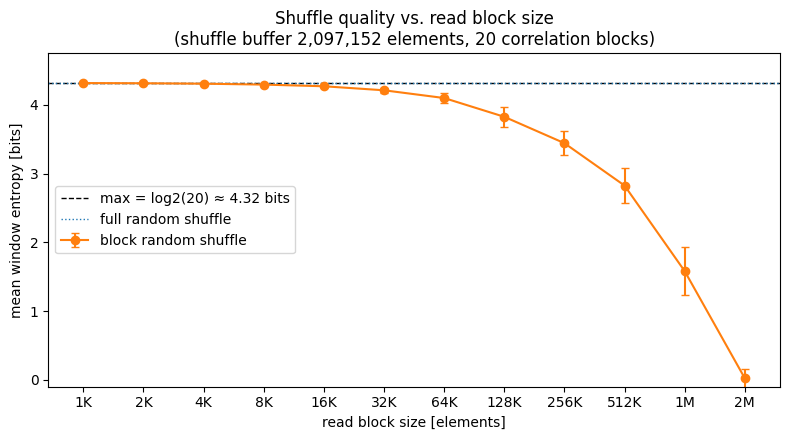

In [8]:
sizes = np.array([r["read_block_size"] for r in sweep])
means = np.array([r["mean_entropy"] for r in sweep])
stds = np.array([r["std_entropy"] for r in sweep])



fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(sizes, means, yerr=stds, marker="o", capsize=3, color="tab:orange",
            label="block random shuffle")
ax.axhline(max_entropy, ls="--", c="k", lw=1, label=f"max = log2({N_BLOCKS}) ≈ {max_entropy:.2f} bits")
ax.axhline(entropies["full random shuffle"].mean(), ls=":", c="tab:blue", lw=1,
           label="full random shuffle")
ax.set_xscale("log", base=2)
ax.set_xticks(sizes, [human_readable(s) for s in sizes])
ax.minorticks_off()
ax.set_xlim(sizes.min() / 1.5, sizes.max() * 1.5)
ax.set(xlabel="read block size [elements]", ylabel="mean window entropy [bits]",
       ylim=(-0.1, max_entropy * 1.1))
ax.legend(loc="center left")
ax.set_title(f"Shuffle quality vs. read block size\n"
             f"(shuffle buffer {SHUFFLE_BUFFER_SIZE:,} elements, {N_BLOCKS} correlation blocks)")

fig.tight_layout()
plt.show()

## 5. Scaling read block size and shuffle buffer size in tandem

Does absolute size matter, or only the *ratio*? Here read block size and shuffle buffer size are scaled
**together** (starting from the defaults and doubling/halving in lockstep), keeping the number of resident read
blocks constant at `SHUFFLE_BUFFER_SIZE / READ_BLOCK_SIZE` = 512. If only the ratio matters, shuffle quality
should stay constant across the sweep.

In [9]:
# scale both sizes in tandem: ratio (resident read blocks) stays constant
RATIO = SHUFFLE_BUFFER_SIZE // READ_BLOCK_SIZE  # 512 read blocks in the buffer
tandem_sweep = []
for read_block_size in 2 ** np.arange(8, 24):  # 256 ... 8,388,608
    buffer_size = read_block_size * RATIO
    if buffer_size > N_ELEMENTS:
        break  # buffer larger than the dataset -> trivially a full shuffle
    t0 = time.perf_counter()
    stream = block_random_shuffle(dataset, N_BLOCKS, int(read_block_size), int(buffer_size),
                                  np.random.default_rng(SEED))
    h = windowed_entropy(stream, ENTROPY_WINDOW, N_BLOCKS)
    tandem_sweep.append({"read_block_size": int(read_block_size), "buffer_size": int(buffer_size),
                         "mean_entropy": h.mean(), "std_entropy": h.std()})
    print(f"read block {int(read_block_size):>9,}, buffer {int(buffer_size):>12,}: "
          f"mean window entropy {h.mean():.4f} bits ({h.mean() / max_entropy:6.2%} of max), "
          f"took {time.perf_counter() - t0:5.1f} s")

read block       256, buffer      131,072: mean window entropy 4.3098 bits (99.72% of max), took  19.1 s


read block       512, buffer      262,144: mean window entropy 4.3094 bits (99.71% of max), took  11.0 s


read block     1,024, buffer      524,288: mean window entropy 4.3088 bits (99.70% of max), took   7.5 s


read block     2,048, buffer    1,048,576: mean window entropy 4.3089 bits (99.70% of max), took   5.7 s


read block     4,096, buffer    2,097,152: mean window entropy 4.3094 bits (99.71% of max), took   4.4 s


read block     8,192, buffer    4,194,304: mean window entropy 4.3082 bits (99.68% of max), took   3.8 s


read block    16,384, buffer    8,388,608: mean window entropy 4.3101 bits (99.73% of max), took   3.7 s


read block    32,768, buffer   16,777,216: mean window entropy 4.3104 bits (99.73% of max), took   3.5 s


read block    65,536, buffer   33,554,432: mean window entropy 4.3126 bits (99.78% of max), took   3.3 s


read block   131,072, buffer   67,108,864: mean window entropy 4.3198 bits (99.95% of max), took   3.2 s


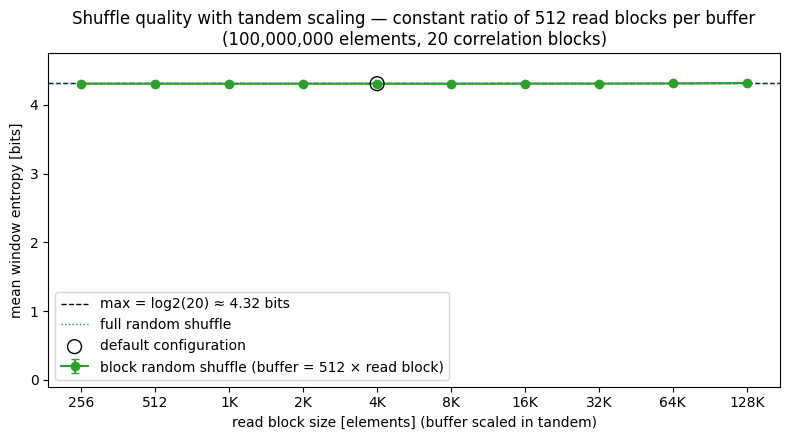

In [10]:
sizes = np.array([r["read_block_size"] for r in tandem_sweep])
means = np.array([r["mean_entropy"] for r in tandem_sweep])
stds = np.array([r["std_entropy"] for r in tandem_sweep])
default = tandem_sweep[np.searchsorted(sizes, READ_BLOCK_SIZE)]

plt.figure(figsize=(8, 4.5))
plt.errorbar(sizes, means, yerr=stds, marker="o", capsize=3, color="tab:green",
             label=f"block random shuffle (buffer = {RATIO} × read block)")
plt.axhline(max_entropy, ls="--", c="k", lw=1, label=f"max = log2({N_BLOCKS}) ≈ {max_entropy:.2f} bits")
plt.axhline(entropies["full random shuffle"].mean(), ls=":", c="tab:blue", lw=1,
            label="full random shuffle")
plt.scatter([default["read_block_size"]], [default["mean_entropy"]], s=100, facecolors="none",
            edgecolors="k", zorder=3, label="default configuration")
plt.xscale("log", base=2)
plt.xticks(sizes, [human_readable(s) for s in sizes])
plt.minorticks_off()
plt.xlabel("read block size [elements] (buffer scaled in tandem)")
plt.ylabel("mean window entropy [bits]")
plt.ylim(-0.1, max_entropy * 1.1)
plt.legend()
plt.title(f"Shuffle quality with tandem scaling — constant ratio of {RATIO} read blocks per buffer\n"
          f"({N_ELEMENTS:,} elements, {N_BLOCKS} correlation blocks)")
plt.tight_layout()
plt.show()

## 6. Shuffle quality vs. buffer-to-read-block ratio

Sections 4 and 5 showed that quality degrades with larger read blocks at fixed buffer size, but stays constant
when both are scaled in tandem — suggesting the **ratio** `shuffle buffer size / read block size` (i.e. the
number of independently positioned read blocks resident in the buffer) is the controlling parameter. This plot
collects every simulated configuration from both sweeps and plots shuffle quality against that ratio.

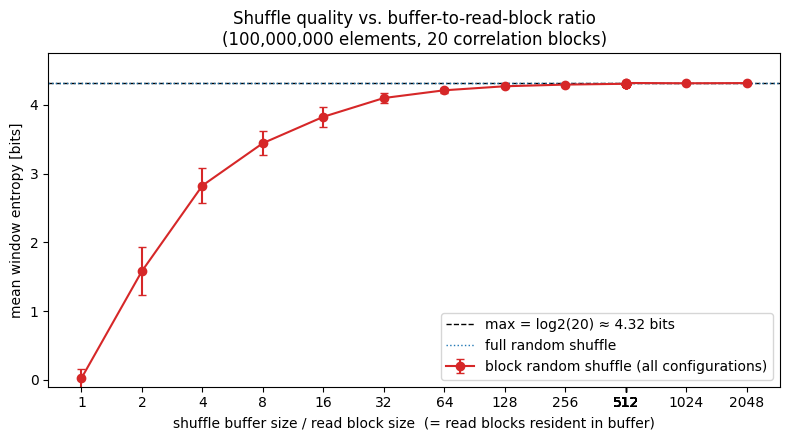

In [11]:
# collect all simulated configurations from the sweeps in sections 4 and 5
ratio_points = (
    [(SHUFFLE_BUFFER_SIZE / r["read_block_size"], r["mean_entropy"], r["std_entropy"]) for r in sweep]
    + [(r["buffer_size"] / r["read_block_size"], r["mean_entropy"], r["std_entropy"]) for r in tandem_sweep]
)
ratio_points.sort()

ratios = np.array([p[0] for p in ratio_points])
means = np.array([p[1] for p in ratio_points])
stds = np.array([p[2] for p in ratio_points])

plt.figure(figsize=(8, 4.5))
plt.errorbar(ratios, means, yerr=stds, marker="o", capsize=3, color="tab:red",
             label="block random shuffle (all configurations)")
plt.axhline(max_entropy, ls="--", c="k", lw=1, label=f"max = log2({N_BLOCKS}) ≈ {max_entropy:.2f} bits")
plt.axhline(entropies["full random shuffle"].mean(), ls=":", c="tab:blue", lw=1,
            label="full random shuffle")
plt.xscale("log", base=2)
plt.xticks(ratios, [str(int(r)) for r in ratios])
plt.minorticks_off()
plt.xlabel("shuffle buffer size / read block size  (= read blocks resident in buffer)")
plt.ylabel("mean window entropy [bits]")
plt.ylim(-0.1, max_entropy * 1.1)
plt.legend()
plt.title(f"Shuffle quality vs. buffer-to-read-block ratio\n"
          f"({N_ELEMENTS:,} elements, {N_BLOCKS} correlation blocks)")
plt.tight_layout()
plt.show()

## Observations

- The **full random shuffle** sits essentially at the theoretical maximum of `log2(N_BLOCKS)` bits for every
  window — adjacent outputs are (almost) independent draws from all correlation blocks.
- The **block random shuffle** nearly matches it, despite performing only contiguous reads: at any moment the
  buffer holds `SHUFFLE_BUFFER_SIZE / READ_BLOCK_SIZE` = 512 read blocks sampled from random dataset positions,
  i.e. a mixture of (nearly) all correlation blocks. The residual entropy deficit comes from the finite buffer:
  the value mixture in the buffer fluctuates around the ideal uniform mixture.
- The **unshuffled reference** stays near 0 bits inside the correlation blocks and spikes only at block
  boundaries — the autocorrelated baseline both strategies start from.

**Knobs to explore:** decreasing `SHUFFLE_BUFFER_SIZE` or increasing `READ_BLOCK_SIZE` reduces the number of
independent read blocks resident in the buffer and visibly lowers the entropy of the block shuffle;
increasing `N_BLOCKS` makes the buffer mixture sparser with the same effect.

The sweep in section 4 confirms this picture: shuffle quality is essentially optimal as long as many
more read blocks than correlation blocks fit into the shuffle buffer, and degrades quickly once only a
handful of read blocks are resident.

Scaling read block size and shuffle buffer size **in tandem** (section 5) leaves shuffle quality
essentially unchanged: only the *ratio* — the number of independently positioned read blocks resident in
the buffer — matters, not the absolute sizes. If anything, larger absolute sizes help slightly, because a
larger buffer covers more of the remaining dataset and refills disturb the buffer's value mixture less.

Plotting all simulated configurations against the buffer-to-read-block **ratio** (section 6) collapses
both sweeps onto a single curve: quality rises monotonically with the number of resident read blocks and
is essentially optimal once the buffer holds roughly 2-4× as many read blocks as there are correlation
blocks.